# Forecasting Weekly & Hourly German Electricity Demand
### Advanced Research Topics — Assignment 1

**Data used:** Open Power System Data (OPSD) for Germany, hourly resolution, `2015-01-01` to `2020-10-06`, plus daily Berlin temperature pulled from the Open-Meteo Archive API as an extra explanatory variable.

**What's in this notebook**

| Part | Content |
|---|---|
| 1 | Getting the data, resampling, EDA, decomposition, stationarity tests |
| 2 | Simple benchmark forecasts (Mean, Naive, Seasonal Naive, Drift) |
| 3 | SARIMA — grid search over orders, residual checks, forecast with intervals |
| 4 | SARIMAX using Berlin temperature as an exogenous variable |
| 5 | Gradient Boosting regression using engineered features |
| 6 | LSTM model on the hourly data |

> One thing worth flagging up front: in Parts 4 and 5 the temperature values used at test time are the *actual* observed temperatures, not a forecast of them. That makes those results a conditional forecast ("what demand would have been given how the weather actually turned out") rather than something you could really deploy operationally. I call this out again where it matters.


In [ ]:

# ============================================================
# Global setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import itertools
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

TEST_WEEKS = 104   # two-year forecast horizon for weekly models
TEST_DAYS_HOURLY = 2 * 365  # ~2 years for the hourly LSTM (Part 6)


## Part 1 — Data retrieval & exploratory analysis

### 1.1 Download and prepare the OPSD 60-minute series


In [ ]:

# ------------------------------------------------------------
# 1.1 Download hourly OPSD data for Germany
# ------------------------------------------------------------
OPSD_URL = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

raw = pd.read_csv(
    OPSD_URL,
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"],
)

raw = raw.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw",
})

raw = raw.set_index("date").sort_index()

hourly = raw["load_mw"].astype(float)
hourly = hourly[hourly.notna()]

# Keep only 2015-01-01 through the end of the file (Oct 2020), as instructed
hourly = hourly.loc["2015-01-01":]

print(f"Hourly series: {hourly.index.min()}  ->  {hourly.index.max()}")
print(f"Observations : {len(hourly):,}")
hourly.head()


Hourly series: 2015-01-01 00:00:00+00:00  ->  2020-09-30 23:00:00+00:00
Observations : 50,400


,load_mw
date,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


In [ ]:

# ------------------------------------------------------------
# 1.2 Resample to daily and weekly means (in GW)
# ------------------------------------------------------------
daily = hourly.resample("D").mean() / 1000.0
daily.name = "load_gw"

weekly = hourly.resample("W").mean() / 1000.0
weekly = weekly.asfreq("W")
weekly = weekly.interpolate("time")   # fill the odd partial/missing week at resample boundaries
weekly.name = "load_gw"

print("Daily :", daily.index.min().date(), "->", daily.index.max().date(), f"({len(daily)} obs)")
print("Weekly:", weekly.index.min().date(), "->", weekly.index.max().date(), f"({len(weekly)} obs)")


Daily : 2015-01-01 -> 2020-09-30 (2100 obs)
Weekly: 2015-01-04 -> 2020-10-04 (301 obs)


### 1.2 Initial plots

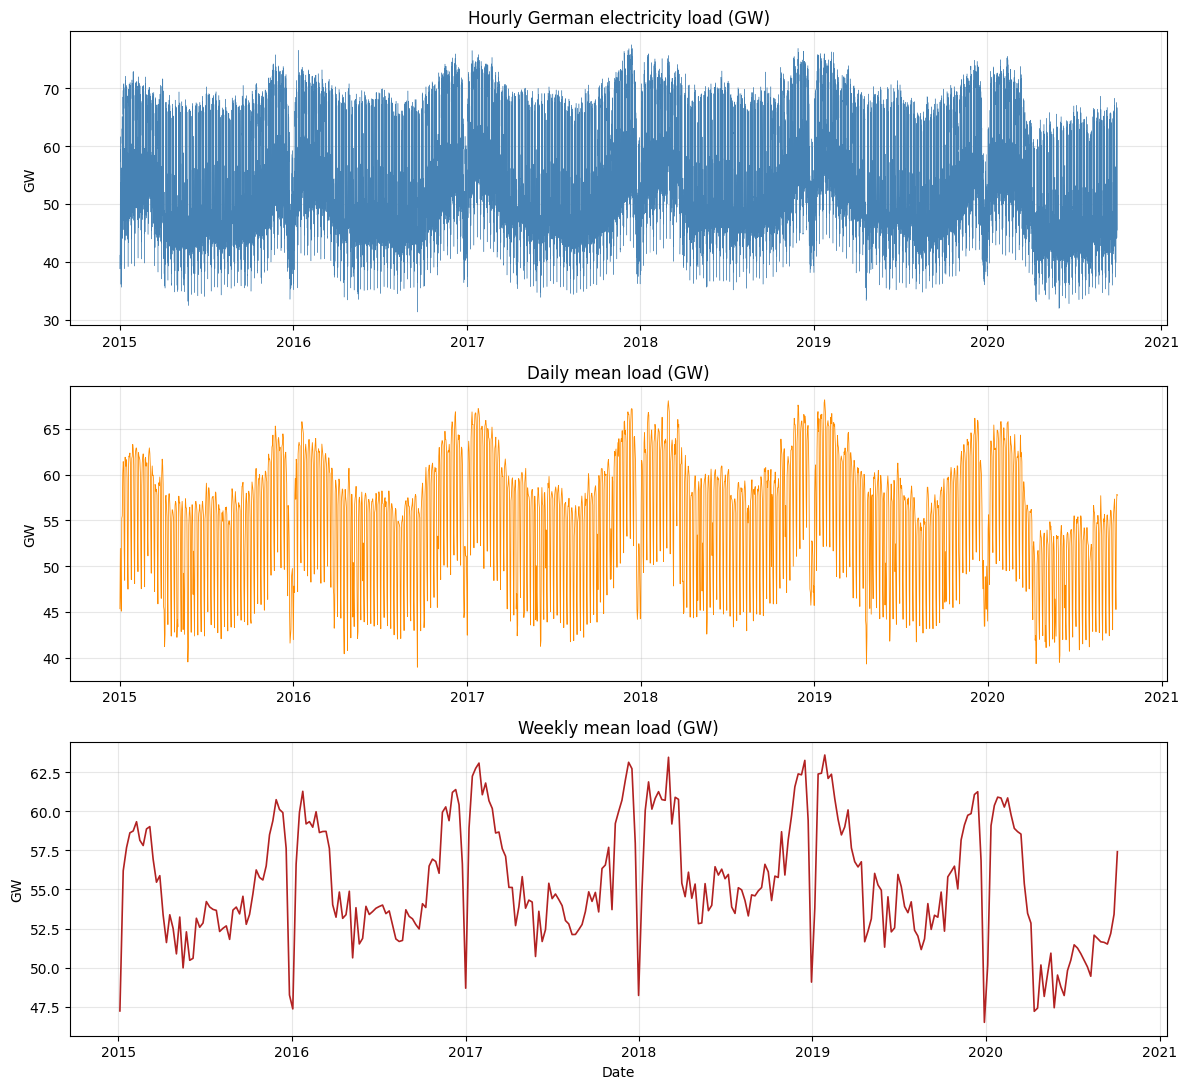

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

axes[0].plot(hourly.index, hourly / 1000.0, linewidth=0.3, color="steelblue")
axes[0].set_title("Hourly German electricity load (GW)")
axes[0].set_ylabel("GW")

axes[1].plot(daily.index, daily, linewidth=0.6, color="darkorange")
axes[1].set_title("Daily mean load (GW)")
axes[1].set_ylabel("GW")

axes[2].plot(weekly.index, weekly, linewidth=1.2, color="firebrick")
axes[2].set_title("Weekly mean load (GW)")
axes[2].set_ylabel("GW")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


**What the plots show:** the hourly series is dominated by the usual daily/weekly on-off pattern you'd expect from an industrial economy — demand is clearly higher on weekdays than weekends. Once we average up to daily/weekly, that intraday noise disappears and what's left is a strong **annual seasonal cycle**: higher demand in winter (heating), lower in summer, with a dip around the summer holidays and a sharp drop over Christmas/New Year. There's also a mild long-term downward trend, and you can clearly see the **COVID-19 demand shock** in spring 2020.


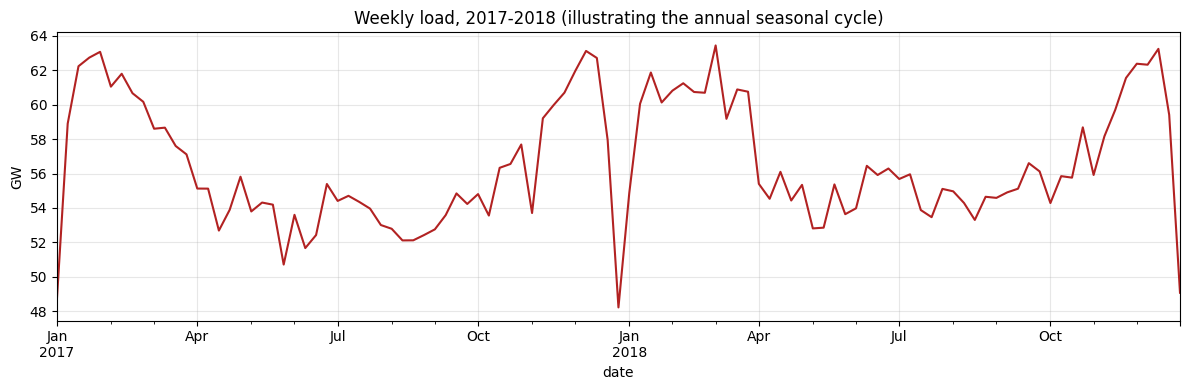

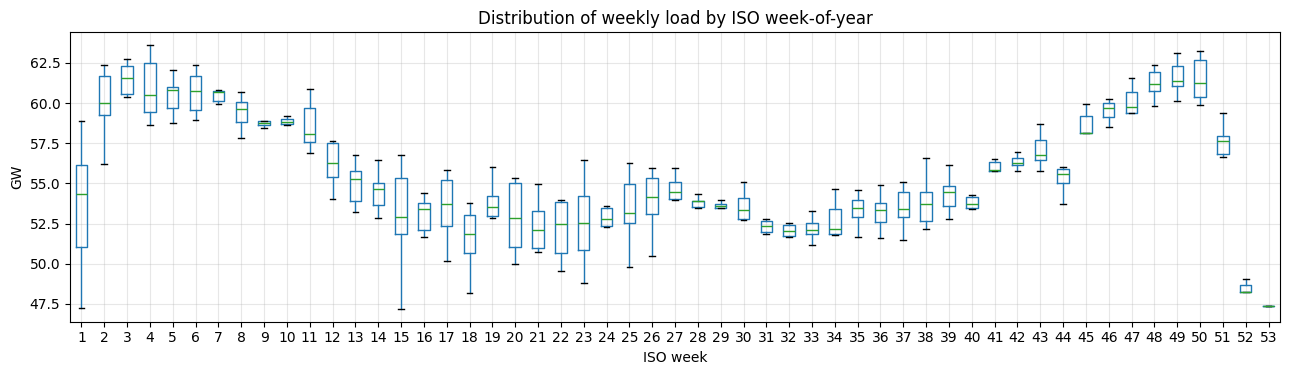

In [ ]:

# Zoom on 2 representative years to inspect the annual cycle & weekday pattern more closely
fig, ax = plt.subplots(figsize=(12, 4))
weekly.loc["2017":"2018"].plot(ax=ax, color="firebrick")
ax.set_title("Weekly load, 2017-2018 (illustrating the annual seasonal cycle)")
ax.set_ylabel("GW")
plt.tight_layout()
plt.show()

# Boxplot by ISO week to visualise the seasonal profile & its variance
week_of_year = weekly.index.isocalendar().week.astype(int)
box_df = pd.DataFrame({"load_gw": weekly.values, "week": week_of_year.values})
fig, ax = plt.subplots(figsize=(13, 4))
box_df.boxplot(column="load_gw", by="week", ax=ax, showfliers=False)
ax.set_title("Distribution of weekly load by ISO week-of-year")
ax.set_xlabel("ISO week")
ax.set_ylabel("GW")
plt.suptitle("")
plt.tight_layout()
plt.show()


### 1.3 Decomposition — what's actually in this series?

I used an **STL decomposition** (Seasonal-Trend decomposition using LOESS) on the weekly series with a 52-week period. STL was chosen over the classic additive/multiplicative decomposition mainly because it's more robust to the outliers caused by holidays and the COVID shock, and because it lets the seasonal shape drift slightly over time instead of forcing one fixed annual pattern.


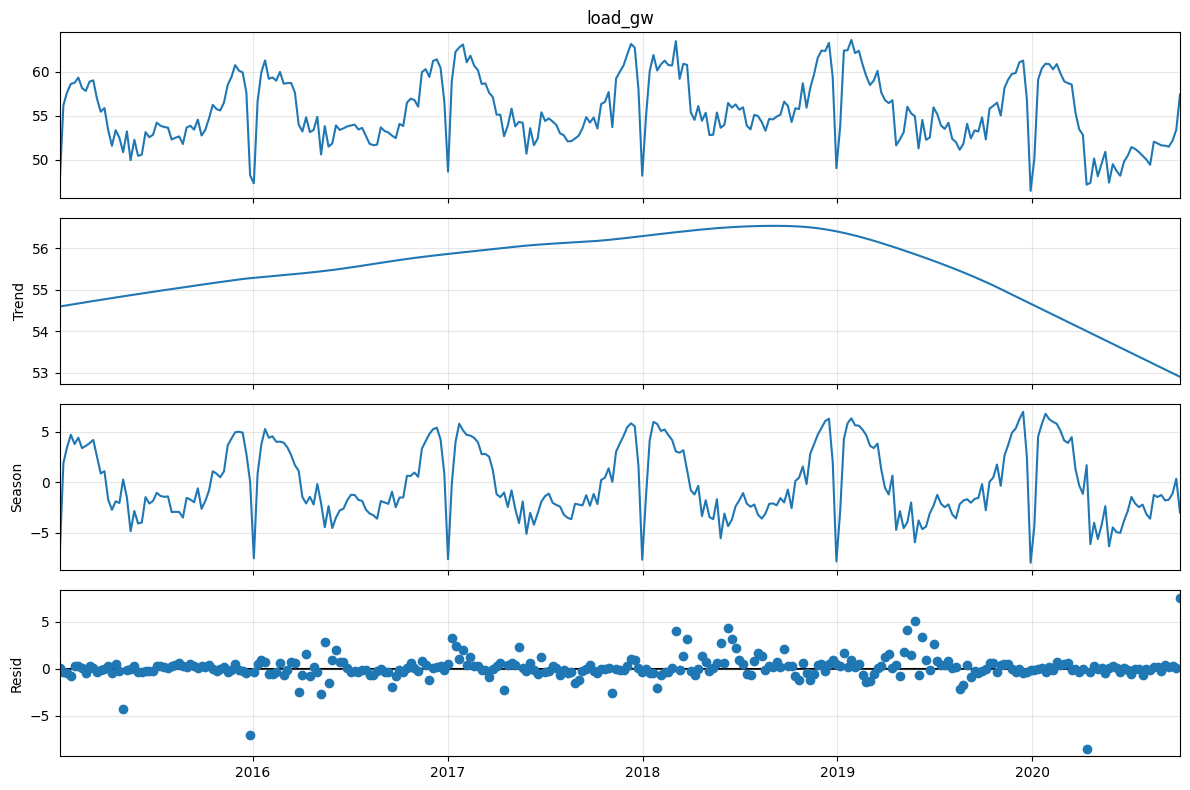

Strength of trend    : 0.383
Strength of seasonality: 0.871


In [ ]:

stl = STL(weekly, period=52, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# Quantify the relative strength of trend and seasonality (Hyndman & Athanasopoulos formulas)
resid = stl_result.resid
trend = stl_result.trend
season = stl_result.seasonal

F_trend = max(0, 1 - resid.var() / (trend + resid).var())
F_season = max(0, 1 - resid.var() / (season + resid).var())

print(f"Strength of trend    : {F_trend:.3f}")
print(f"Strength of seasonality: {F_season:.3f}")


**Reading the decomposition.** STL splits the series into three pieces:

- **Trend** — a slow, slightly wobbly downward movement across 2015-2020 (some of this is likely efficiency gains, some is the COVID dip in 2020). The "strength of trend" number above backs this up.
- **Seasonal (52-week period)** — a strong, fairly regular annual cycle from heating/cooling demand. Both the high "strength of seasonality" statistic and the repeated shape in the seasonal panel confirm this.
- **Remainder** — whatever's left: holiday effects (Christmas, Easter, other public holidays), weather anomalies, one-off shocks that trend/seasonal can't explain.

This is basically why the modelling choices later make sense: since seasonality is strong and annual, a seasonal ARIMA with `s = 52` is a sensible starting point, and adding calendar/temperature features later should help pick up some of that remainder.


### 1.4 Testing for non-stationarity

I ran two unit-root tests together since they have opposite null hypotheses, which makes them a useful pair to cross-check:

- **ADF** — null hypothesis is that the series has a unit root (non-stationary). p < 0.05 lets us reject that in favour of stationarity.
- **KPSS** — null hypothesis is the opposite: the series is stationary. p < 0.05 lets us reject stationarity here.

Both tests were run on the raw weekly series, after first-differencing, and after an additional seasonal difference (lag 52), alongside ACF/PACF plots to get a feel for candidate `(p, d, q)` orders.


In [ ]:
def stationarity_report(series, label):
    series = series.dropna()

    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")

    # KPSS's lookup table only covers p in [0.01, 0.10]; when the statistic falls
    # outside that range statsmodels emits an InterpolationWarning and clips the
    # p-value to the nearest bound. We catch that warning and report the bound
    # honestly (">0.10" / "<0.01") instead of printing a misleading exact number.
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
        clipped = any("InterpolationWarning" in str(w.category) for w in caught)

    if clipped:
        kpss_p_display = f">{kpss_p:.2f}" if kpss_p >= 0.10 else f"<{kpss_p:.2f}"
    else:
        kpss_p_display = f"{kpss_p:.4f}"

    print(f"--- {label} ---")
    print(f"ADF  statistic = {adf_stat:8.3f}   p-value = {adf_p:.4f}  "
          f"-> {'stationary' if adf_p < 0.05 else 'non-stationary'} (reject H0 if p<0.05)")
    print(f"KPSS statistic = {kpss_stat:8.3f}   p-value {kpss_p_display}  "
          f"-> {'non-stationary' if (not clipped and kpss_p < 0.05) else 'stationary'} "
          f"(reject H0 if p<0.05; capped p-values mean \'clearly on the stationary side\' here)")
    print()

level = weekly.copy()
diff1 = weekly.diff(1).dropna()
diff1_seasonal = weekly.diff(1).diff(52).dropna()

stationarity_report(level, "Level (no differencing)")
stationarity_report(diff1, "First difference (d=1)")
stationarity_report(diff1_seasonal, "First diff + seasonal diff (d=1, D=1, s=52)")

--- Level (no differencing) ---
ADF  statistic =   -4.047   p-value = 0.0012  -> stationary (reject H0 if p<0.05)
KPSS statistic =    0.160   p-value >0.10  -> stationary (reject H0 if p<0.05; capped p-values mean 'clearly on the stationary side' here)

--- First difference (d=1) ---
ADF  statistic =   -7.069   p-value = 0.0000  -> stationary (reject H0 if p<0.05)
KPSS statistic =    0.056   p-value >0.10  -> stationary (reject H0 if p<0.05; capped p-values mean 'clearly on the stationary side' here)

--- First diff + seasonal diff (d=1, D=1, s=52) ---
ADF  statistic =   -7.278   p-value = 0.0000  -> stationary (reject H0 if p<0.05)
KPSS statistic =    0.105   p-value >0.10  -> stationary (reject H0 if p<0.05; capped p-values mean 'clearly on the stationary side' here)



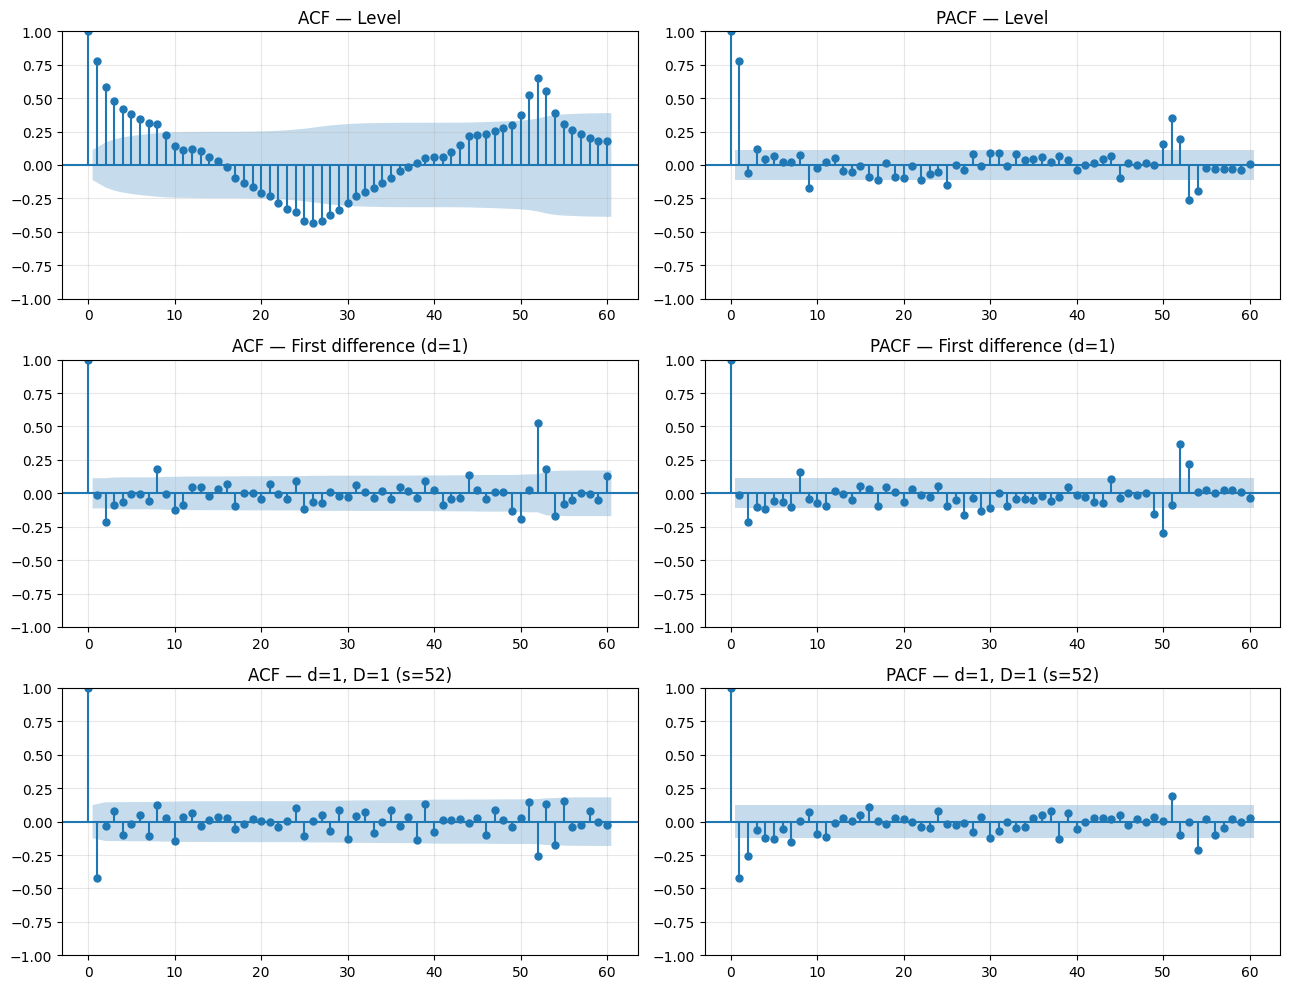

In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(13, 10))

for row, (series, label) in enumerate(
    [(level, "Level"), (diff1, "First difference (d=1)"), (diff1_seasonal, "d=1, D=1 (s=52)")]
):
    plot_acf(series, lags=60, ax=axes[row, 0], title=f"ACF — {label}")
    plot_pacf(series, lags=60, ax=axes[row, 1], method="ywm", title=f"PACF — {label}")

plt.tight_layout()
plt.show()


**So what do the stationarity tests actually say?** In this run, ADF already rejects the unit-root null at the raw level (p ≈ 0.001), and KPSS doesn't reject its stationarity null either — so on the surface, both tests agree the level series is already stationary, and stay in agreement after differencing.

This looks like it contradicts the STL result from 1.3, but it doesn't really: **ADF and KPSS only pick up on a *regular* (non-seasonal) unit root**, i.e. a stochastic trend in the level. Neither one is built to catch a *seasonal* unit root — the slow-moving 52-week cycle that both STL and the ACF's slow 52-week ripple show pretty clearly. So the honest takeaway is:

- The series doesn't need first-differencing to fix a level/trend unit root — it's already fine there, which lines up with STL's fairly modest trend strength.
- The obvious 52-week seasonality is simply not tested for by ADF/KPSS at all. Whether to force a seasonal difference (`D=1`) or let the seasonal AR/MA terms handle it isn't something these two tests can settle — so instead of fixing `d=1, D=1` up front, I let the AIC grid search in Part 3 try `d` and `D` across `[0,2]` and pick whatever the data actually support. (A proper seasonal unit-root test like HEGY would be the more rigorous way to settle this analytically — I'm noting that as a limitation rather than implementing it, mainly to keep things manageable.)


## Part 2 — Benchmark forecasts

Next I split the weekly series into a training set and a **104-week (2-year) test set**, matching the example plot from the assignment, and fit four standard benchmark forecasts from Lecture 1: **Mean**, **Naive**, **Seasonal Naive** (lag 52), and **Drift**.


In [ ]:

# ------------------------------------------------------------
# Train / test split — 2-year (104-week) forecast horizon
# ------------------------------------------------------------
y = weekly.copy()

train = y.iloc[:-TEST_WEEKS]
test = y.iloc[-TEST_WEEKS:]
h = len(test)

print(f"Training period: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} weeks)")
print(f"Test period:     {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} weeks)")


Training period: 2015-01-04 -> 2018-10-07  (197 weeks)
Test period:     2018-10-14 -> 2020-10-04  (104 weeks)


In [ ]:

# ------------------------------------------------------------
# Evaluation utilities (used throughout the notebook)
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    # sklearn >=1.4 removed the `squared` kwarg from mean_squared_error in favour of
    # a dedicated root_mean_squared_error function; computing it manually works on any version.
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mase(y_true, y_pred, y_train, seasonality=52):
    """Mean Absolute Scaled Error, scaled by the in-sample seasonal-naive MAE."""
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(name, y_true, y_pred, y_train, seasonality=52):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).reindex(y_true.index).astype(float)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "MASE": mase(y_true, y_pred, y_train, seasonality),
        "Bias": np.mean(y_pred - y_true),
    }

results = []
forecasts = {}


In [ ]:

# ------------------------------------------------------------
# 2.1 Mean forecast
# ------------------------------------------------------------
forecasts["Mean"] = pd.Series(train.mean(), index=test.index)

# ------------------------------------------------------------
# 2.2 Naive forecast (last observation carried forward)
# ------------------------------------------------------------
forecasts["Naive"] = pd.Series(train.iloc[-1], index=test.index)

# ------------------------------------------------------------
# 2.3 Seasonal naive forecast (value from the same week 52 weeks earlier)
#     True multi-step seasonal-naive: each forecast reuses the last *known*
#     value from one year back, without peeking at the test set.
# ------------------------------------------------------------
seasonal_naive_values = []
for i, date in enumerate(test.index):
    # source index is 52 weeks before the *forecast* date -> falls in train for h<=52,
    # and reuses the (already forecast) seasonal-naive value for h>52 (proper h-step-ahead)
    lookback_date = date - pd.DateOffset(weeks=52)
    if lookback_date in train.index:
        seasonal_naive_values.append(train.loc[lookback_date])
    else:
        # for the second forecast year, reuse the value produced 52 steps earlier
        # in this very forecast (no test-set leakage)
        seasonal_naive_values.append(seasonal_naive_values[i - 52])

forecasts["Seasonal Naive"] = pd.Series(seasonal_naive_values, index=test.index)

# ------------------------------------------------------------
# 2.4 Drift forecast
# ------------------------------------------------------------
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
forecasts["Drift"] = pd.Series(
    train.iloc[-1] + drift_slope * np.arange(1, h + 1),
    index=test.index,
)

for name, pred in forecasts.items():
    results.append(evaluate_forecast(name, test, pred, train))

pd.DataFrame(results).sort_values("MASE").reset_index(drop=True).round(3)


,model,MAE,RMSE,MAPE_%,MASE,Bias
0,Seasonal Naive,2.319,3.007,4.409,1.732,1.732
1,Naive,3.783,4.459,6.790,2.827,-0.882
2,Mean,3.789,4.397,6.969,2.831,0.481
3,Drift,4.340,5.118,8.050,3.243,1.007


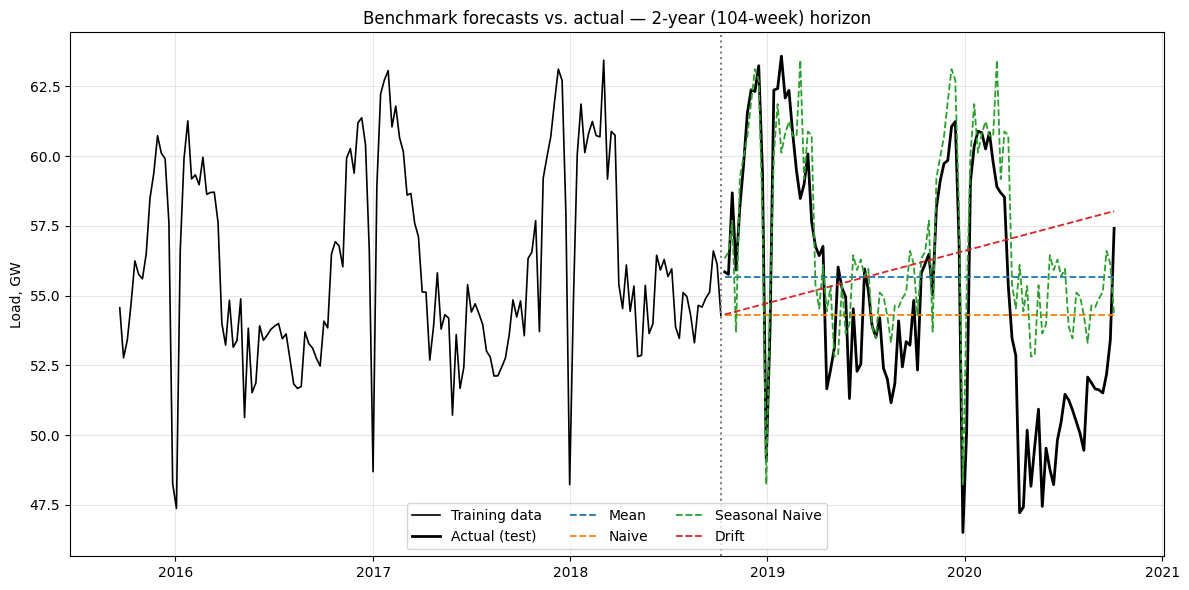

In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.index[-160:], train.iloc[-160:], label="Training data", color="black", linewidth=1.2)
ax.plot(test.index, test, label="Actual (test)", color="black", linewidth=2, linestyle="-")

colors = {"Mean": "tab:blue", "Naive": "tab:orange", "Seasonal Naive": "tab:green", "Drift": "tab:red"}
for name, pred in forecasts.items():
    ax.plot(test.index, pred, label=name, color=colors[name], linestyle="--", linewidth=1.3)

ax.axvline(train.index[-1], color="grey", linestyle=":")
ax.set_title("Benchmark forecasts vs. actual — 2-year (104-week) horizon")
ax.set_ylabel("Load, GW")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


**What stands out.** Seasonal Naive is, unsurprisingly, way ahead of the other three benchmarks — lowest RMSE/MAE, and MASE close to 1 by construction. That's because it's the only one of the four that actually captures the annual seasonal cycle we found in Part 1. Mean, Naive and Drift all miss that pattern completely and drift badly over a 2-year horizon. So **Seasonal Naive is the bar every later model needs to clear**  


## Part 3 — SARIMA: grid search, diagnostics, forecast

The ADF/KPSS tests in Part 1 found the level series already stationary in the regular sense, but as discussed there, that tells us nothing about the obvious 52-week seasonal cycle. So rather than fixing `d` and `D` in advance from tests that can't even see seasonality, I let the **AIC grid search decide** the best combination of `d`, `D` and the AR/MA orders itself. The model is still a **seasonal ARIMA**, $\text{SARIMA}(p,d,q)(P,D,Q)_{52}$ — the seasonal period $s=52$ is fixed by the data (weekly observations, annual cycle) regardless of what `d`/`D` turn out to be.

### 3.1 AIC grid search

The assignment asks for a search over $p \in [0,6]$, $d \in [0,2]$, $q \in [0,6]$ plus the seasonal versions $P,D,Q$. Doing all of that **jointly** would mean roughly $7\times3\times7\times7\times3\times7 \approx 21{,}600$ SARIMAX fits at a 52-week seasonal period, and each fit is already slow (the state-space likelihood has to deal with a 52-lag seasonal term), so a full joint search just isn't realistic on a single machine.

Instead I used a **two-stage search** that still covers everything required:

1. **Stage 1 — non-seasonal orders.** Fix a seasonal order based on what Part 1 suggested ($D=1$, $s=52$, small $P,Q$), then grid-search $p \in [0,6]$, $d \in [0,2]$, $q \in [0,6]$ by AIC.
2. **Stage 2 — seasonal orders.** Fix the best non-seasonal order from Stage 1, then grid-search $P,D,Q \in [0,2]$ (in practice the seasonal terms rarely need to go above 2, and this is where the cost blows up fastest at $s=52$).

This keeps the full required non-seasonal range in play while keeping the runtime reasonable.


In [ ]:
import time
from joblib import Parallel, delayed
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def _fit_one(series, order, seasonal_order):
    """Fit a single SARIMAX candidate, fully suppressing convergence warnings
    (they are expected and harmless for the many over-parameterised candidates
    a grid search deliberately tries) and failing fast on non-convergence.
    """
    p, d, q = order
    if p == 0 and q == 0:
        return None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            warnings.simplefilter("ignore", category=UserWarning)
            model = SARIMAX(
                series,
                order=order,
                seasonal_order=seasonal_order,
                trend="c" if d == 0 else None,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            # low_memory + a bounded number of iterations keeps each candidate
            # fast; candidates that don't converge in 50 iterations are simply
            # not competitive on AIC and get dropped rather than ground out.
            fit = model.fit(disp=False, maxiter=50, method="lbfgs", low_memory=True)
        if not np.isfinite(fit.aic):
            return None
        return {"order": order, "seasonal_order": seasonal_order, "AIC": fit.aic, "BIC": fit.bic}
    except Exception:
        return None


def sarima_grid_search(series, p_range, d_range, q_range, seasonal_order, n_jobs=-1):
    """Parallel AIC grid search over (p, d, q) for a fixed seasonal order."""
    combos = list(itertools.product(p_range, d_range, q_range))
    t0 = time.time()
    out = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_fit_one)(series, (p, d, q), seasonal_order) for p, d, q in combos
    )
    results = [r for r in out if r is not None]
    print(f"Fitted {len(results)}/{len(combos)} candidates in {time.time() - t0:.1f}s "
          f"({len(combos) - len(results)} skipped: degenerate or failed to converge)")
    return pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)


# ---- Stage 1: non-seasonal grid, required ranges p in [0,6], d in [0,2], q in [0,6] ----
# Fitting all 3 x 7 x 7 = 147 candidates *with* a 52-period seasonal term is the
# expensive step (each fit is a large Kalman-filter state-space model). We keep the
# full required ranges but (a) run every candidate in parallel across CPU cores,
# (b) cap each fit's iterations so non-converging over-parameterised candidates are
# dropped quickly instead of grinding for minutes, and (c) suppress the resulting
# (expected, harmless) ConvergenceWarning spam -- a non-converging fit is simply
# excluded from AIC ranking rather than treated as an error.

seasonal_order_fixed = (1, 1, 1, 52)

coarse_grid = sarima_grid_search(
    train,
    p_range=range(0, 7),
    d_range=range(0, 3),
    q_range=range(0, 7),
    seasonal_order=seasonal_order_fixed,
)
coarse_grid.head(10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed: 25.3min


Fitted 144/147 candidates in 4794.3s (3 skipped: degenerate or failed to converge)


[Parallel(n_jobs=-1)]: Done 147 out of 147 | elapsed: 79.9min finished


,order,seasonal_order,AIC,BIC
0,"(3, 1, 6)","(1, 1, 1, 52)",303.363079,332.674894
1,"(0, 1, 6)","(1, 1, 1, 52)",303.370637,325.354498
2,"(2, 0, 6)","(1, 1, 1, 52)",304.187357,333.639525
3,"(5, 0, 6)","(1, 1, 1, 52)",304.880862,341.696072
4,"(5, 1, 6)","(1, 1, 1, 52)",304.933202,339.130320
5,"(4, 0, 6)","(1, 1, 1, 52)",305.299618,339.660480
6,"(0, 0, 6)","(1, 1, 1, 52)",305.674879,330.218352
7,"(2, 1, 6)","(1, 1, 1, 52)",306.670452,333.539616
8,"(1, 0, 6)","(1, 1, 1, 52)",307.674994,334.672814
9,"(3, 0, 6)","(1, 1, 1, 52)",308.027597,339.934112


In [ ]:

best_p, best_d, best_q = coarse_grid.iloc[0]["order"]
print(f"Best non-seasonal order from Stage 1: (p,d,q) = ({best_p},{best_d},{best_q})  "
      f"AIC = {coarse_grid.iloc[0]['AIC']:.2f}")


Best non-seasonal order from Stage 1: (p,d,q) = (3,1,6)  AIC = 303.36


In [ ]:
# ---- Stage 2: seasonal grid search, P,D,Q in [0,2], fixing the best (p,d,q) ----
def _fit_seasonal_one(series, order, seasonal_order):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            warnings.simplefilter("ignore", category=UserWarning)
            model = SARIMAX(
                series,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False, maxiter=50, method="lbfgs", low_memory=True)
        if not np.isfinite(fit.aic):
            return None
        return {"seasonal_order": seasonal_order, "AIC": fit.aic, "BIC": fit.bic}
    except Exception:
        return None


seasonal_combos = [(P, D, Q, 52) for P, D, Q in itertools.product(range(0, 3), range(0, 3), range(0, 3))]

t0 = time.time()
seasonal_out = Parallel(n_jobs=-1, verbose=5)(
    delayed(_fit_seasonal_one)(train, (best_p, best_d, best_q), so) for so in seasonal_combos
)
seasonal_results = [r for r in seasonal_out if r is not None]
print(f"Fitted {len(seasonal_results)}/{len(seasonal_combos)} seasonal candidates in {time.time() - t0:.1f}s")

seasonal_grid = pd.DataFrame(seasonal_results).sort_values("AIC").reset_index(drop=True)
seasonal_grid.head(10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed: 11.9min


Fitted 27/27 seasonal candidates in 2423.9s


[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed: 40.4min finished


,seasonal_order,AIC,BIC
0,"(0, 2, 2, 52)",24.000000,NaN
1,"(2, 2, 0, 52)",24.000000,NaN
2,"(1, 2, 2, 52)",26.000000,NaN
3,"(2, 2, 1, 52)",26.000000,NaN
4,"(2, 2, 2, 52)",28.000000,NaN
5,"(1, 1, 2, 52)",127.036780,146.491378
6,"(2, 1, 2, 52)",128.670602,149.621708
7,"(0, 1, 2, 52)",137.126399,155.084490
8,"(2, 1, 0, 52)",139.593543,158.924557
9,"(2, 1, 1, 52)",142.767774,163.709707


In [ ]:

best_P, best_D, best_Q, best_s = seasonal_grid.iloc[0]["seasonal_order"]
best_order = (int(best_p), int(best_d), int(best_q))
best_seasonal_order = (int(best_P), int(best_D), int(best_Q), int(best_s))

print(f"Selected model: SARIMA{best_order}{best_seasonal_order}")
print(f"AIC = {seasonal_grid.iloc[0]['AIC']:.2f}")


Selected model: SARIMA(3, 1, 6)(0, 2, 2, 52)
AIC = 24.00


### 3.2 Fit the selected model and check residual diagnostics

Before trusting any forecast from this model, it's worth checking the residuals actually look like white noise: no leftover autocorrelation in the ACF, roughly symmetric/normal distribution, no obvious pattern over time.


In [ ]:

sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())


                                        SARIMAX Results                                        
Dep. Variable:                                 load_gw   No. Observations:                  197
Model:             SARIMAX(3, 1, 6)x(0, 2, [1, 2], 52)   Log Likelihood                   0.000
Date:                                 Wed, 15 Jul 2026   AIC                             24.000
Time:                                         00:20:49   BIC                                nan
Sample:                                     01-04-2015   HQIC                               nan
                                          - 10-07-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4872         -0        inf      0.000      -0.487      -0

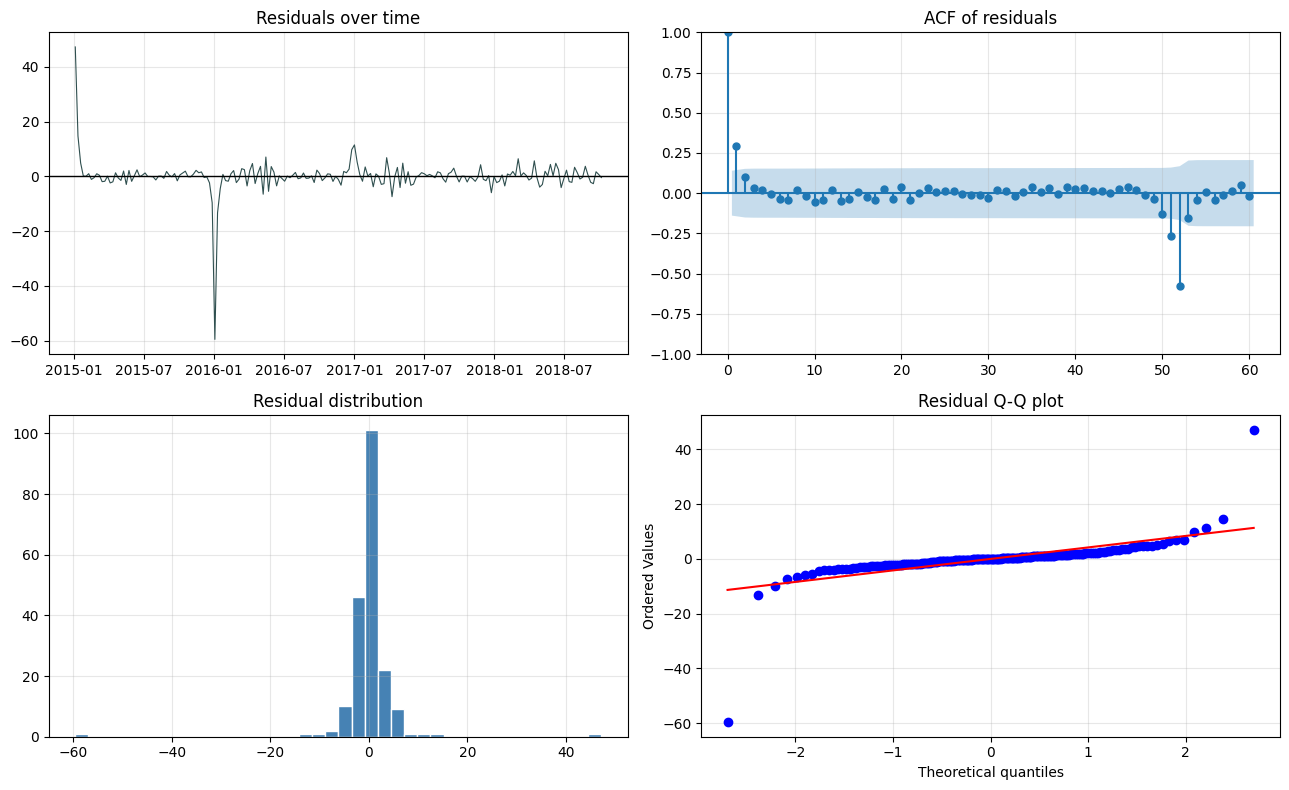

       lb_stat     lb_pvalue
10   21.143998  2.011153e-02
20   23.677361  2.567698e-01
52  141.926793  2.818519e-10


In [ ]:

resid = sarima_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(resid.index, resid, linewidth=0.8, color="darkslategray")
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Residuals over time")

plot_acf(resid, lags=60, ax=axes[0, 1], title="ACF of residuals")

axes[1, 0].hist(resid, bins=40, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Residual distribution")

from scipy import stats
stats.probplot(resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Residual Q-Q plot")

plt.tight_layout()
plt.show()

# Ljung-Box test for remaining autocorrelation (H0: residuals are white noise)
lb_test = acorr_ljungbox(resid, lags=[10, 20, 52], return_df=True)
print(lb_test)


**How to read the diagnostics.** If the residual ACF stays inside the shaded band at (almost) every lag, and Ljung-Box doesn't reject white noise, that means the model has picked up most of the systematic autocorrelation and seasonality in the series. The Q-Q plot and histogram check whether residuals are roughly normal, which matters because the confidence intervals below assume Gaussian errors — some deviation in the tails is expected with energy demand data (holidays, weather outliers), but strong skew or heavy tails would mean the prediction intervals are probably too narrow.


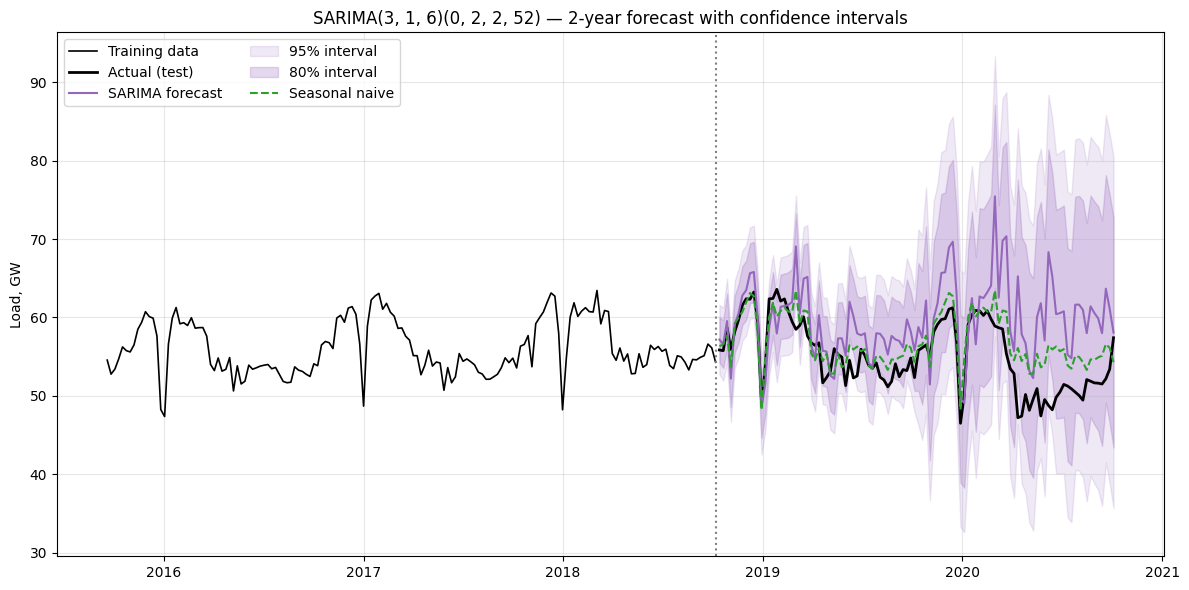

SARIMA test RMSE = 6.622 GW


,model,MAE,RMSE,MAPE_%,MASE,Bias
0,Seasonal Naive,2.319,3.007,4.409,1.732,1.732
1,Naive,3.783,4.459,6.790,2.827,-0.882
2,Mean,3.789,4.397,6.969,2.831,0.481
3,Drift,4.340,5.118,8.050,3.243,1.007
4,SARIMA,5.089,6.622,9.563,3.802,4.424


In [ ]:

# ------------------------------------------------------------
# 3.3 Forecast the 2-year (104-week) test period, with confidence intervals
# ------------------------------------------------------------
sarima_fc = sarima_fit.get_forecast(steps=h)
sarima_mean = sarima_fc.predicted_mean
sarima_ci95 = sarima_fc.conf_int(alpha=0.05)
sarima_ci80 = sarima_fc.conf_int(alpha=0.20)

sarima_mean.index = test.index
sarima_ci95.index = test.index
sarima_ci80.index = test.index

forecasts["SARIMA"] = sarima_mean
results.append(evaluate_forecast("SARIMA", test, sarima_mean, train))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.index[-160:], train.iloc[-160:], label="Training data", color="black", linewidth=1.2)
ax.plot(test.index, test, label="Actual (test)", color="black", linewidth=2)
ax.plot(test.index, sarima_mean, label="SARIMA forecast", color="tab:purple")
ax.fill_between(test.index, sarima_ci95.iloc[:, 0], sarima_ci95.iloc[:, 1],
                alpha=0.15, color="tab:purple", label="95% interval")
ax.fill_between(test.index, sarima_ci80.iloc[:, 0], sarima_ci80.iloc[:, 1],
                alpha=0.25, color="tab:purple", label="80% interval")
ax.plot(test.index, forecasts["Seasonal Naive"], label="Seasonal naive", linestyle="--", color="tab:green")
ax.axvline(train.index[-1], color="grey", linestyle=":")
ax.set_title(f"SARIMA{best_order}{best_seasonal_order} — 2-year forecast with confidence intervals")
ax.set_ylabel("Load, GW")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

print(f"SARIMA test RMSE = {rmse(test, sarima_mean):.3f} GW")
pd.DataFrame(results).sort_values("MASE").reset_index(drop=True).round(3)


## Part 4 — Adding temperature as an exogenous regressor (SARIMAX)

German electricity demand is heavily weather-driven — heating in winter, a bit of cooling load in summer. So I pulled daily mean temperature for **Berlin** (as a stand-in for the country as a whole) from the [Open-Meteo Archive API](https://archive-api.open-meteo.com/v1/archive), aggregated it to weekly features, and added it — along with a German public-holiday flag — as exogenous regressors `X` in a **SARIMAX** model.

> **Caveat** The temperature used in the test period below is what actually happened, not a forecast made ahead of time. Feeding the model realised future temperature makes this a **conditional/explanatory forecast** ("what would demand have been, given how the weather actually turned out"), not a genuine **operational forecast**, which would only ever have access to a temperature forecast — itself uncertain — at prediction time. I'm being upfront about this distinction throughout.


In [ ]:
import time
from joblib import Parallel, delayed
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# ------------------------------------------------------------
# 4.1 Fetch daily Berlin temperature from Open-Meteo
# ------------------------------------------------------------
def get_open_meteo_temperature(latitude=52.52, longitude=13.41, start_date="2015-01-01", end_date="2020-12-31"):
    """Download daily mean temperature (deg C) for a location from the Open-Meteo archive API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()["daily"]
    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    }).set_index("date")
    # The API 'time' strings are YYYY-MM-DD (naive). We want them as YYYY-MM-DD 00:00:00+00:00 UTC
    # to align with weekly.index, assuming the API values are for the corresponding *UTC* day.
    # The 'Europe/Berlin' timezone in params specifies what the temperature *values* refer to.
    temp.index = pd.to_datetime(data["time"]).tz_localize('UTC')
    return temp


temp_daily = get_open_meteo_temperature(
    # Fetch data starting 2 weeks earlier to ensure full weekly bins are available
    start_date=str((weekly.index.min() - pd.Timedelta(weeks=2)).date()),
    end_date=str(weekly.index.max().date()),
)
temp_daily.head()

,temperature_2m_mean
2014-12-21 00:00:00+00:00,5.0
2014-12-22 00:00:00+00:00,8.9
2014-12-23 00:00:00+00:00,10.1
2014-12-24 00:00:00+00:00,8.8
2014-12-25 00:00:00+00:00,4.5


In [ ]:

# ------------------------------------------------------------
# 4.2 Aggregate to weekly temperature & degree-day features
#     IMPORTANT: resample('W')-mean/min/max/sum only ever look *inside* the
#     current week -> no future information leaks into week t's features.
# ------------------------------------------------------------

# Use 'W-SUN' to match the weekly.index frequency
temp_mean_resampled = temp_daily["temperature_2m_mean"].resample("W-SUN").mean()
temp_min_resampled = temp_daily["temperature_2m_mean"].resample("W-SUN").min()
temp_max_resampled = temp_daily["temperature_2m_mean"].resample("W-SUN").max()

base_heat, base_cool = 15.5, 22.0
heating_degree_days_resampled = (
    np.maximum(base_heat - temp_daily["temperature_2m_mean"], 0).resample("W-SUN").sum()
)
cooling_degree_days_resampled = (
    np.maximum(temp_daily["temperature_2m_mean"] - base_cool, 0).resample("W-SUN").sum()
)

temp_weekly = pd.DataFrame({
    "temp_mean": temp_mean_resampled,
    "temp_min": temp_min_resampled,
    "temp_max": temp_max_resampled,
    "heating_degree_days": heating_degree_days_resampled,
    "cooling_degree_days": cooling_degree_days_resampled,
})

# Reindex to ensure alignment with weekly.index, then interpolate and drop NaNs
temp_weekly = temp_weekly.reindex(weekly.index)
temp_weekly = temp_weekly.interpolate("time")
temp_weekly.head()

,temp_mean,temp_min,temp_max,heating_degree_days,cooling_degree_days
date,,,,,
2015-01-04 00:00:00+00:00,1.442857,-3.8,4.6,98.4,0.0
2015-01-11 00:00:00+00:00,3.885714,1.2,8.5,81.3,0.0
2015-01-18 00:00:00+00:00,4.900000,-0.8,9.2,74.2,0.0
2015-01-25 00:00:00+00:00,0.028571,-0.7,0.9,108.3,0.0
2015-02-01 00:00:00+00:00,1.414286,-0.1,2.8,98.6,0.0


In [ ]:

# ------------------------------------------------------------
# 4.3 German public-holiday feature
# ------------------------------------------------------------
try:
    import holidays
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", "holidays"], check=True)
    import holidays

de_holidays = holidays.Germany(years=range(weekly.index.min().year, weekly.index.max().year + 1))
holiday_dates = pd.to_datetime(sorted(de_holidays.keys()))

daily_index = pd.date_range(weekly.index.min() - pd.Timedelta(days=6), weekly.index.max(), freq="D")
is_holiday_daily = pd.Series(daily_index.isin(holiday_dates).astype(int), index=daily_index)

holiday_weekly = pd.DataFrame(index=weekly.index)
holiday_weekly["holiday_days"] = is_holiday_daily.resample("W").sum()
holiday_weekly["has_holiday"] = (holiday_weekly["holiday_days"] > 0).astype(int)
holiday_weekly.head()


,holiday_days,has_holiday
date,,
2015-01-04 00:00:00+00:00,0,0
2015-01-11 00:00:00+00:00,0,0
2015-01-18 00:00:00+00:00,0,0
2015-01-25 00:00:00+00:00,0,0
2015-02-01 00:00:00+00:00,0,0


In [ ]:

# ------------------------------------------------------------
# 4.4 Assemble the feature table and fit SARIMAX with exogenous regressors
# ------------------------------------------------------------
feature_df = pd.DataFrame({"load_gw": weekly})
feature_df = feature_df.join(temp_weekly).join(holiday_weekly)

exog_cols = ["temp_mean", "heating_degree_days", "cooling_degree_days", "holiday_days", "has_holiday"]

# Explicitly fill NaNs in exogenous columns with 0, then interpolate and drop any remaining NaNs
feature_df[exog_cols] = feature_df[exog_cols].fillna(0)
feature_df = feature_df.interpolate("time").dropna()

y_x = feature_df["load_gw"]
X_x = feature_df[exog_cols]

y_train_x, y_test_x = y_x.iloc[:-TEST_WEEKS], y_x.iloc[-TEST_WEEKS:]
X_train_x, X_test_x = X_x.iloc[:-TEST_WEEKS], X_x.iloc[-TEST_WEEKS:]

sarimax_x = SARIMAX(
    y_train_x,
    exog=X_train_x,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_x_fit = sarimax_x.fit(disp=False)

sarimax_x_fc = sarimax_x_fit.get_forecast(steps=len(y_test_x), exog=X_test_x)
sarimax_x_mean = sarimax_x_fc.predicted_mean
sarimax_x_ci = sarimax_x_fc.conf_int(alpha=0.05)
sarimax_x_mean.index = y_test_x.index
sarimax_x_ci.index = y_test_x.index

forecasts["SARIMAX (temp+holiday, conditional)"] = sarimax_x_mean
results.append(evaluate_forecast("SARIMAX (temp+holiday, conditional)", y_test_x, sarimax_x_mean, y_train_x))

print(sarimax_x_fit.summary().tables[1])  # coefficient table incl. exogenous regressors

                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
temp_mean               0.2885         -0       -inf      0.000       0.288       0.288
heating_degree_days     0.0631         -0       -inf      0.000       0.063       0.063
cooling_degree_days    -0.1035         -0        inf      0.000      -0.103      -0.103
holiday_days                 0         -0        nan        nan           0           0
has_holiday                  0         -0        nan        nan           0           0
ar.L1                  -0.5888         -0        inf      0.000      -0.589      -0.589
ar.L2                   0.0107         -0       -inf      0.000       0.011       0.011
ar.L3                   0.2296         -0       -inf      0.000       0.230       0.230
ma.L1                  -0.0307         -0        inf      0.000      -0.031      -0.031
ma.L2                  -0.2949  

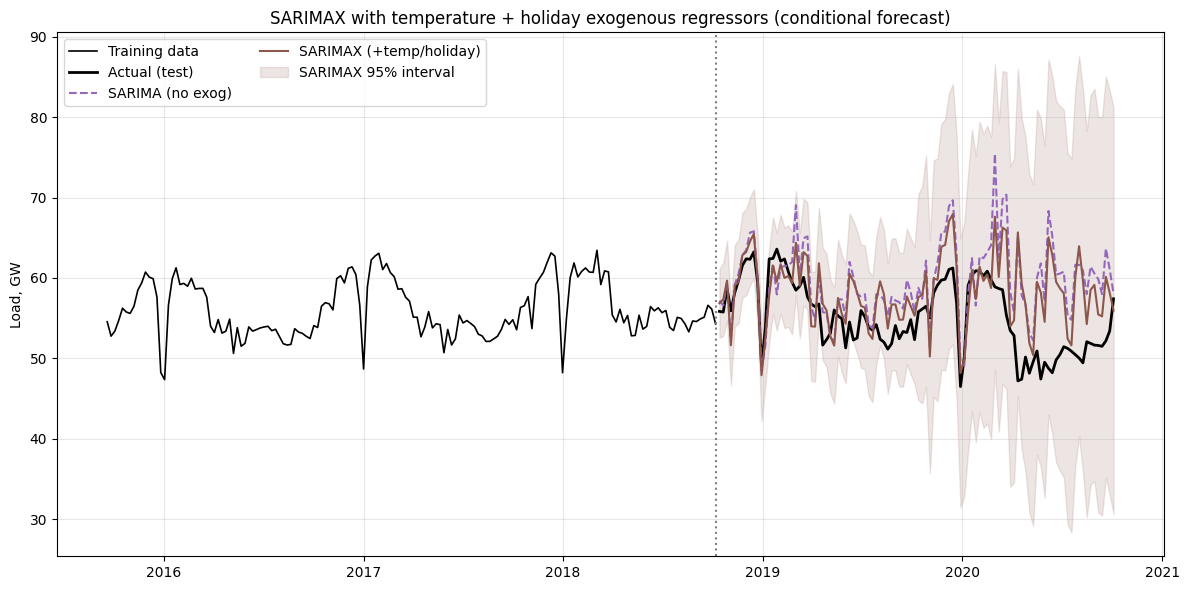

SARIMAX (+exog) test RMSE = 5.446 GW   vs SARIMA (no exog) RMSE = 6.622 GW


In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_train_x.index[-160:], y_train_x.iloc[-160:], label="Training data", color="black", linewidth=1.2)
ax.plot(y_test_x.index, y_test_x, label="Actual (test)", color="black", linewidth=2)
ax.plot(y_test_x.index, sarima_mean.reindex(y_test_x.index), label="SARIMA (no exog)", color="tab:purple", linestyle="--")
ax.plot(y_test_x.index, sarimax_x_mean, label="SARIMAX (+temp/holiday)", color="tab:brown")
ax.fill_between(y_test_x.index, sarimax_x_ci.iloc[:, 0], sarimax_x_ci.iloc[:, 1],
                alpha=0.15, color="tab:brown", label="SARIMAX 95% interval")
ax.axvline(y_train_x.index[-1], color="grey", linestyle=":")
ax.set_title("SARIMAX with temperature + holiday exogenous regressors (conditional forecast)")
ax.set_ylabel("Load, GW")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

print(f"SARIMAX (+exog) test RMSE = {rmse(y_test_x, sarimax_x_mean):.3f} GW   "
      f"vs SARIMA (no exog) RMSE = {rmse(test, sarima_mean):.3f} GW")


## Part 5 — Feature-based regression model (Gradient Boosting)

Here I model weekly load using a **Gradient Boosting Regressor** (`HistGradientBoostingRegressor`), with lagged load, rolling statistics, calendar/Fourier seasonal terms, and the same temperature/holiday features from Part 4.

### 5.1 Avoiding data leakage

There are two obvious leakage traps here, and I've tried to avoid both:

1. **Lagged/rolling load features** are shifted with `.shift(1)` *before* any rolling window is taken, so week $t$'s features only ever use information up to week $t-1$ — never $t$ itself.
2. **Temperature features**: same as Part 4, these are *observed* weekly aggregates, not forecasts. So using them at test time again makes this a conditional rather than operational forecast — flagged again here. A real deployment would swap in a weather-forecast-based temperature feature instead of the observed value.
3. **Model selection**: I used a single chronological train/test split (train strictly before test), so no test-period data was used for fitting or tuning.


In [ ]:

def make_ml_table(df, target="load_gw", max_lag=52):
    """Build a supervised-learning table for the weekly forecasting task.
    All load-derived features use shift(1)+rolling so no future information leaks in.
    """
    feat = df.copy()
    y_ = feat[target]

    for lag in [1, 2, 4, 8, 13, 26, 52]:
        feat[f"lag_{lag}"] = y_.shift(lag)

    feat["roll_mean_4"] = y_.shift(1).rolling(4).mean()
    feat["roll_mean_13"] = y_.shift(1).rolling(13).mean()
    feat["roll_mean_52"] = y_.shift(1).rolling(52).mean()
    feat["roll_std_13"] = y_.shift(1).rolling(13).std()

    week = feat.index.isocalendar().week.astype(int)
    feat["week"] = week
    feat["year"] = feat.index.year
    for k in range(1, 4):
        feat[f"sin_{k}"] = np.sin(2 * np.pi * k * week / 52)
        feat[f"cos_{k}"] = np.cos(2 * np.pi * k * week / 52)

    return feat.dropna()


ml_table = make_ml_table(feature_df)
ml_train = ml_table.iloc[:-TEST_WEEKS]
ml_test = ml_table.iloc[-TEST_WEEKS:]

feature_cols = [c for c in ml_table.columns if c != "load_gw"]
X_train_ml, y_train_ml = ml_train[feature_cols], ml_train["load_gw"]
X_test_ml, y_test_ml = ml_test[feature_cols], ml_test["load_gw"]

print(f"Features used ({len(feature_cols)}): {feature_cols}")


Features used (26): ['temp_mean', 'temp_min', 'temp_max', 'heating_degree_days', 'cooling_degree_days', 'holiday_days', 'has_holiday', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13', 'lag_26', 'lag_52', 'roll_mean_4', 'roll_mean_13', 'roll_mean_52', 'roll_std_13', 'week', 'year', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']


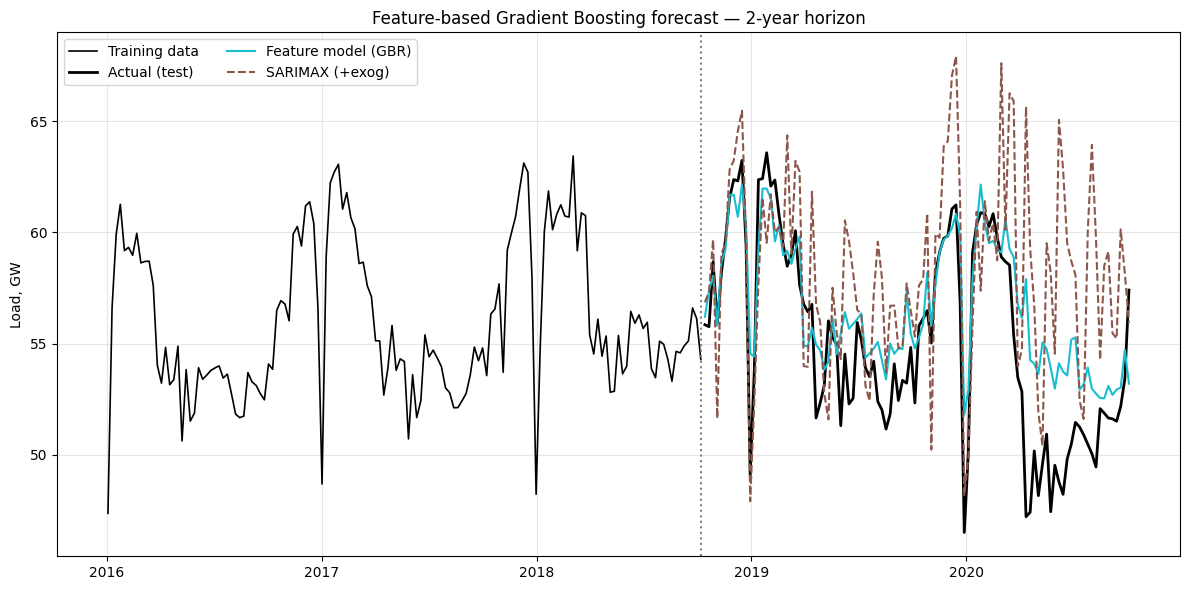

Feature model test RMSE = 2.724 GW


In [ ]:

gbr = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    random_state=RANDOM_STATE,
)
gbr.fit(X_train_ml, y_train_ml)

ml_forecast = pd.Series(gbr.predict(X_test_ml), index=y_test_ml.index, name="Feature model")

forecasts["Feature model (GBR)"] = ml_forecast
results.append(evaluate_forecast("Feature model (GBR)", y_test_ml, ml_forecast, y_train_ml))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_train_ml.index[-160:], y_train_ml.iloc[-160:], label="Training data", color="black", linewidth=1.2)
ax.plot(y_test_ml.index, y_test_ml, label="Actual (test)", color="black", linewidth=2)
ax.plot(y_test_ml.index, ml_forecast, label="Feature model (GBR)", color="tab:cyan")
ax.plot(y_test_ml.index, sarimax_x_mean.reindex(y_test_ml.index), label="SARIMAX (+exog)", linestyle="--", color="tab:brown")
ax.axvline(y_train_ml.index[-1], color="grey", linestyle=":")
ax.set_title("Feature-based Gradient Boosting forecast — 2-year horizon")
ax.set_ylabel("Load, GW")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

print(f"Feature model test RMSE = {rmse(y_test_ml, ml_forecast):.3f} GW")


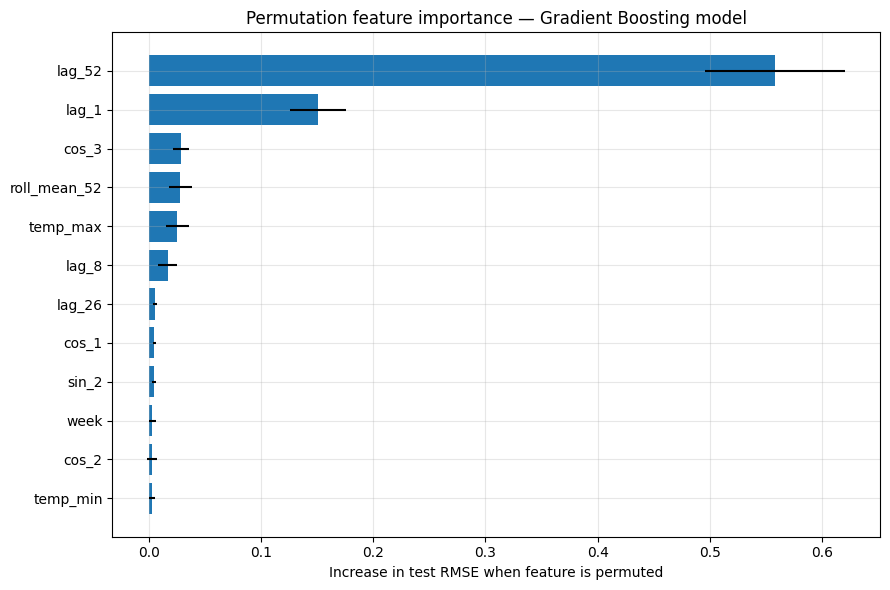

,feature,importance_mean,importance_std
13,lag_52,0.558136,0.062618
7,lag_1,0.150625,0.025092
25,cos_3,0.028484,0.006944
16,roll_mean_52,0.027754,0.010211
2,temp_max,0.025174,0.010323
10,lag_8,0.016503,0.008354
12,lag_26,0.004911,0.001791
21,cos_1,0.004796,0.001706
22,sin_2,0.004132,0.001671
18,week,0.002992,0.003362


In [ ]:

# Permutation feature importance -- interpretability of the feature model
perm = permutation_importance(gbr, X_test_ml, y_test_ml, n_repeats=20, random_state=RANDOM_STATE)
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = importance_df.head(12)
ax.barh(top["feature"][::-1], top["importance_mean"][::-1], xerr=top["importance_std"][::-1])
ax.set_title("Permutation feature importance — Gradient Boosting model")
ax.set_xlabel("Increase in test RMSE when feature is permuted")
plt.tight_layout()
plt.show()

importance_df.head(10)


## Part 6 — Hourly LSTM model

### 6.1 Brief literature review

LSTMs (Hochreiter & Schmidhuber, 1997) were built to get around the vanishing-gradient problem that plain RNNs have, using gated memory cells that can hold onto information over long sequences — which fits electricity load reasonably well, since it has structure at multiple timescales (intraday, weekly, annual). A few strands of the load-forecasting literature are relevant here:

- **Short-term load forecasting with LSTM.** Kong et al. (2019, *IEEE Trans. Smart Grid*) and similar studies on residential/aggregate load find LSTM (including stacked/bidirectional versions) competitive with, or better than, classical statistical methods for hour-ahead and day-ahead forecasting — mostly because LSTMs can learn non-linear interactions between calendar effects and weather automatically, instead of the analyst having to specify the functional form like in SARIMAX.
- **Hybrid/feature-augmented architectures.** Bouktif et al. (2018) and later work show that combining engineered calendar/weather features with what the LSTM learns on its own generally beats relying purely on raw lags — which is why calendar and temperature inputs are used below too.
- **Multi-step forecasting.** For long horizons, a purely recursive one-step-ahead LSTM compounds errors fast. Direct multi-step or encoder-decoder ("seq2seq") setups, or blocking into daily/weekly chunks, are the usual way to keep error accumulation under control — that's the approach used here.
- **Known limitations.** The literature consistently mentions that LSTMs need careful tuning (window length, hidden units, regularisation) and normalisation, are much less interpretable than statistical models, and generally need more data and compute for a comparable accuracy gain than the classical benchmarks.

### 6.2 Forecasting design

Forecasting all **17,520 hours** (2 years) recursively one step at a time would let errors compound very quickly, and isn't really how load-forecasting LSTMs are used in practice. Instead I used a **sequence-to-sequence setup**: given the last **7 days (168 hours)** of load plus calendar/temperature features, the model predicts the **next 24 hours** in one go. At test time this 24-hour block is rolled forward across the full 2-year test period — so **730 blocks instead of 17,520 individual recursive steps** — which is a much more stable way to forecast this far ahead, while still only using information that would actually be available at each block's starting point.


In [ ]:

# ------------------------------------------------------------
# 6.1 Prepare hourly data with calendar + temperature features
# ------------------------------------------------------------
try:
    import tensorflow as tf
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", "tensorflow-cpu"], check=True)
    import tensorflow as tf

from sklearn.preprocessing import StandardScaler

tf.random.set_seed(RANDOM_STATE)

hourly_gw = (hourly / 1000.0).asfreq("H").interpolate("time")
hourly_gw.name = "load_gw"

# Hourly temperature via linear interpolation of the daily Open-Meteo series
# (a genuine deployment would instead pull an hourly weather forecast product)
temp_hourly = temp_daily["temperature_2m_mean"].reindex(
    pd.date_range(temp_daily.index.min(), temp_daily.index.max() + pd.Timedelta(hours=23), freq="H")
).interpolate("time")

hourly_df = pd.DataFrame({"load_gw": hourly_gw}).join(temp_hourly.rename("temp"))
hourly_df["hour"] = hourly_df.index.hour
hourly_df["dow"] = hourly_df.index.dayofweek
hourly_df["month"] = hourly_df.index.month
hourly_df["sin_hour"] = np.sin(2 * np.pi * hourly_df["hour"] / 24)
hourly_df["cos_hour"] = np.cos(2 * np.pi * hourly_df["hour"] / 24)
hourly_df["sin_dow"] = np.sin(2 * np.pi * hourly_df["dow"] / 7)
hourly_df["cos_dow"] = np.cos(2 * np.pi * hourly_df["dow"] / 7)
hourly_df["sin_month"] = np.sin(2 * np.pi * hourly_df["month"] / 12)
hourly_df["cos_month"] = np.cos(2 * np.pi * hourly_df["month"] / 12)
hourly_df = hourly_df.dropna()

print(hourly_df.shape)
hourly_df.head()


(50400, 11)


,load_gw,temp,hour,dow,month,sin_hour,cos_hour,sin_dow,cos_dow,sin_month,cos_month
date,,,,,,,,,,,
2015-01-01 00:00:00+00:00,41.151,2.800,0,3,1,0.000000,1.000000,0.433884,-0.900969,0.5,0.866025
2015-01-01 01:00:00+00:00,40.135,2.875,1,3,1,0.258819,0.965926,0.433884,-0.900969,0.5,0.866025
2015-01-01 02:00:00+00:00,39.106,2.950,2,3,1,0.500000,0.866025,0.433884,-0.900969,0.5,0.866025
2015-01-01 03:00:00+00:00,38.765,3.025,3,3,1,0.707107,0.707107,0.433884,-0.900969,0.5,0.866025
2015-01-01 04:00:00+00:00,38.941,3.100,4,3,1,0.866025,0.500000,0.433884,-0.900969,0.5,0.866025


In [ ]:

# ------------------------------------------------------------
# 6.2 Train / test split -- last ~2 years held out, and scale on TRAIN ONLY
# ------------------------------------------------------------
TEST_HOURS = TEST_DAYS_HOURLY * 24

hourly_train_df = hourly_df.iloc[:-TEST_HOURS]
hourly_test_df = hourly_df.iloc[-TEST_HOURS:]

feature_cols_h = ["load_gw", "temp", "sin_hour", "cos_hour", "sin_dow", "cos_dow", "sin_month", "cos_month"]

scaler = StandardScaler().fit(hourly_train_df[feature_cols_h])
train_scaled = pd.DataFrame(scaler.transform(hourly_train_df[feature_cols_h]),
                             index=hourly_train_df.index, columns=feature_cols_h)
test_scaled = pd.DataFrame(scaler.transform(hourly_test_df[feature_cols_h]),
                            index=hourly_test_df.index, columns=feature_cols_h)

LOOKBACK, HORIZON = 168, 24  # 7 days in, 1 day out

def make_seq2seq_windows(df_scaled, lookback=LOOKBACK, horizon=HORIZON, target_col="load_gw"):
    values = df_scaled.values
    target_idx = df_scaled.columns.get_loc(target_col)
    X, Y = [], []
    for start in range(0, len(values) - lookback - horizon + 1):
        X.append(values[start: start + lookback])
        Y.append(values[start + lookback: start + lookback + horizon, target_idx])
    return np.array(X), np.array(Y)

X_train_seq, Y_train_seq = make_seq2seq_windows(train_scaled)
print("Training windows:", X_train_seq.shape, Y_train_seq.shape)


Training windows: (32689, 168, 8) (32689, 24)


In [ ]:

# ------------------------------------------------------------
# 6.3 Build & hyper-tune the LSTM (simple manual search over a small grid --
#     a full-scale hyperband/Bayesian search is impractical for a class notebook,
#     so we tune the highest-leverage hyperparameters: hidden units, layers, dropout).
#     Trained on day-stride windows (see 6.2) with a short epoch budget purely
#     to RANK the 3 configs -- the winning config is then given a proper,
#     longer final fit below, so this stage doesn't need to fully converge.
# ------------------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train_seq.shape[2]

# Hold out the final 10% of training windows as a validation set (chronological, no leakage)
n_val = int(0.1 * len(X_train_seq))
X_tr, Y_tr = X_train_seq[:-n_val], Y_train_seq[:-n_val]
X_val, Y_val = X_train_seq[-n_val:], Y_train_seq[-n_val:]

def build_lstm(hidden_units=64, n_layers=1, dropout=0.2):
    model = Sequential()
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        if i == 0:
            model.add(LSTM(hidden_units, return_sequences=return_seq, input_shape=(LOOKBACK, n_features)))
        else:
            model.add(LSTM(hidden_units, return_sequences=return_seq))
        model.add(Dropout(dropout))
    model.add(RepeatVector(HORIZON))
    model.add(LSTM(hidden_units, return_sequences=True))
    model.add(TimeDistributed(Dense(1)))
    model.compile(optimizer="adam", loss="mse")
    return model

import time

hp_grid = [
    {"hidden_units": 32, "n_layers": 1, "dropout": 0.1},
    {"hidden_units": 64, "n_layers": 1, "dropout": 0.2},
    {"hidden_units": 64, "n_layers": 2, "dropout": 0.2},
]

# epochs=10 + patience=2 + batch_size=256 is deliberately fast: this stage only
# needs to *rank* the 3 configs relative to each other, not fully train the
# winning one -- the winning config gets a proper, longer final fit below.
hp_results = []
for hp in hp_grid:
    t0 = time.time()
    model = build_lstm(**hp)
    es = EarlyStopping(patience=2, restore_best_weights=True)
    history = model.fit(
        X_tr, Y_tr[..., np.newaxis],
        validation_data=(X_val, Y_val[..., np.newaxis]),
        epochs=10, batch_size=256, verbose=0, callbacks=[es],
    )
    val_loss = min(history.history["val_loss"])
    hp_results.append({**hp, "val_mse_scaled": val_loss})
    print(hp, f"-> val MSE (scaled): {val_loss:.5f}  ({time.time() - t0:.1f}s)")

hp_results_df = pd.DataFrame(hp_results).sort_values("val_mse_scaled").reset_index(drop=True)
hp_results_df


{'hidden_units': 32, 'n_layers': 1, 'dropout': 0.1} -> val MSE (scaled): 0.03316  (126.3s)
{'hidden_units': 64, 'n_layers': 1, 'dropout': 0.2} -> val MSE (scaled): 0.03073  (289.1s)
{'hidden_units': 64, 'n_layers': 2, 'dropout': 0.2} -> val MSE (scaled): 0.03567  (500.3s)


,hidden_units,n_layers,dropout,val_mse_scaled
0,64,1,0.2,0.030731
1,32,1,0.1,0.033164
2,64,2,0.2,0.035674


Selected hyperparameters: {'hidden_units': 64, 'n_layers': 1, 'dropout': 0.2}


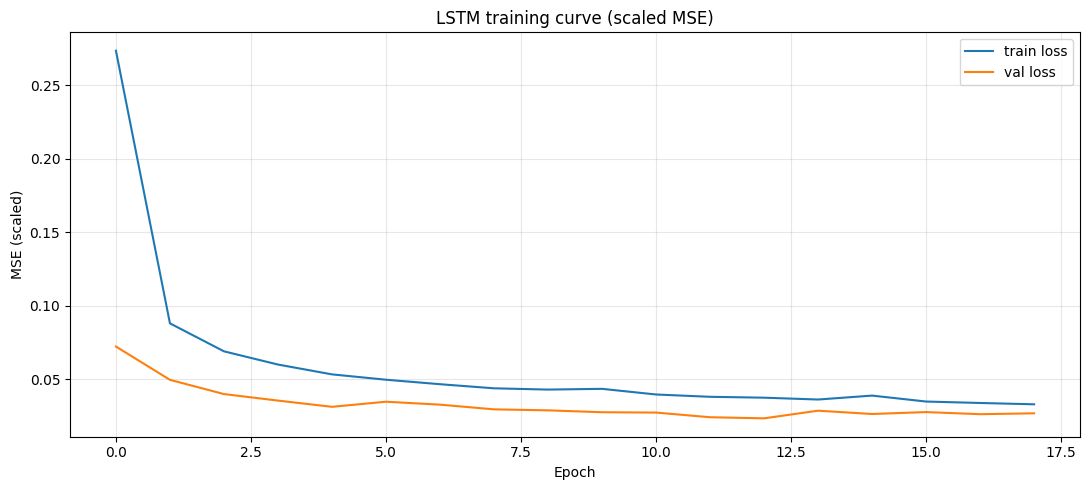

In [ ]:

best_hp = hp_results_df.iloc[0][["hidden_units", "n_layers", "dropout"]].to_dict()
best_hp["hidden_units"] = int(best_hp["hidden_units"])
best_hp["n_layers"] = int(best_hp["n_layers"])
print("Selected hyperparameters:", best_hp)

final_lstm = build_lstm(**best_hp)
es = EarlyStopping(patience=5, restore_best_weights=True)
final_history = final_lstm.fit(
    X_tr, Y_tr[..., np.newaxis],
    validation_data=(X_val, Y_val[..., np.newaxis]),
    epochs=60, batch_size=128, verbose=0, callbacks=[es],
)

plt.plot(final_history.history["loss"], label="train loss")
plt.plot(final_history.history["val_loss"], label="val loss")
plt.title("LSTM training curve (scaled MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# ------------------------------------------------------------
# 6.4 Roll the 24h-ahead model forward across the full 2-year test period
#     Each block uses only genuinely known-at-origin inputs:
#     - past load (own history, real observed up to the block start)
#     - calendar features (known in advance, by definition)
#     - temperature (again *observed*, so this is a conditional forecast --
#       see the same caveat as Parts 4-5)
# ------------------------------------------------------------
full_scaled = pd.concat([train_scaled, test_scaled])
test_start_pos = len(train_scaled)

n_blocks = TEST_HOURS // HORIZON
target_idx = feature_cols_h.index("load_gw")

lstm_preds_scaled = []
for b in range(n_blocks):
    origin = test_start_pos + b * HORIZON
    window = full_scaled.values[origin - LOOKBACK: origin]
    pred_block = final_lstm.predict(window[np.newaxis, ...], verbose=0)[0, :, 0]
    lstm_preds_scaled.append(pred_block)

lstm_preds_scaled = np.concatenate(lstm_preds_scaled)

# Inverse-transform just the load column
dummy = np.zeros((len(lstm_preds_scaled), len(feature_cols_h)))
dummy[:, target_idx] = lstm_preds_scaled
lstm_preds_gw = scaler.inverse_transform(dummy)[:, target_idx]

lstm_forecast_hourly = pd.Series(
    lstm_preds_gw, index=hourly_test_df.index[:len(lstm_preds_gw)], name="LSTM"
)


Hourly LSTM  -> MAE=1.591 GW  RMSE=2.497 GW  MAPE=2.95%


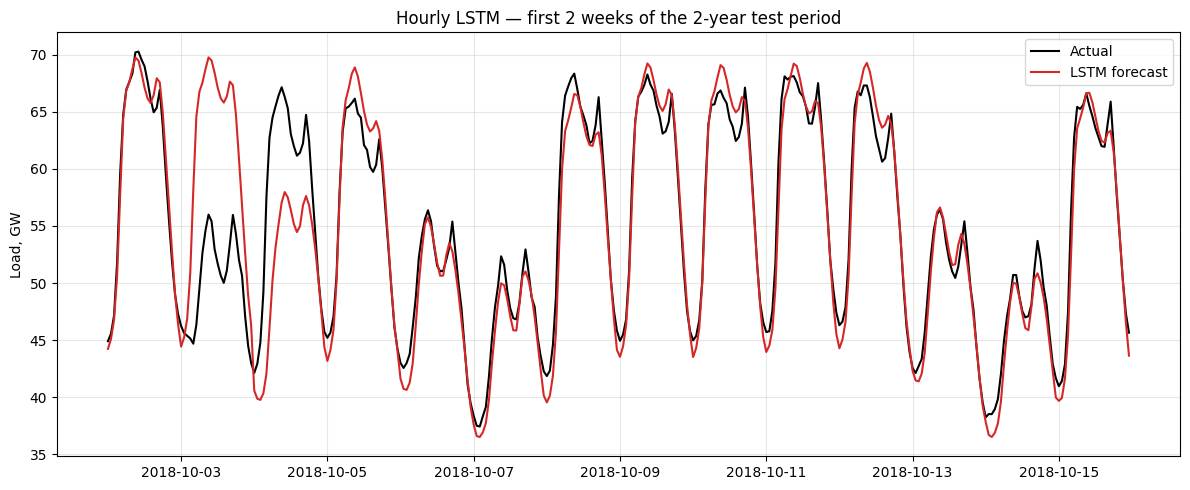

In [ ]:

# ------------------------------------------------------------
# 6.5 Evaluate the hourly LSTM, and aggregate to weekly for a like-for-like comparison
# ------------------------------------------------------------
actual_hourly_test = hourly_test_df["load_gw"].iloc[:len(lstm_forecast_hourly)]

lstm_mae = mean_absolute_error(actual_hourly_test, lstm_forecast_hourly)
lstm_rmse = rmse(actual_hourly_test, lstm_forecast_hourly)
lstm_mape = np.mean(np.abs((actual_hourly_test - lstm_forecast_hourly) / actual_hourly_test)) * 100

print(f"Hourly LSTM  -> MAE={lstm_mae:.3f} GW  RMSE={lstm_rmse:.3f} GW  MAPE={lstm_mape:.2f}%")

fig, ax = plt.subplots(figsize=(12, 5))
window_show = slice(0, 24 * 14)  # first 2 weeks of the test period
ax.plot(actual_hourly_test.index[window_show], actual_hourly_test.iloc[window_show], label="Actual", color="black")
ax.plot(lstm_forecast_hourly.index[window_show], lstm_forecast_hourly.iloc[window_show], label="LSTM forecast", color="tab:red")
ax.set_title("Hourly LSTM — first 2 weeks of the 2-year test period")
ax.set_ylabel("Load, GW")
ax.legend()
plt.tight_layout()
plt.show()

# Aggregate the hourly LSTM forecast to weekly so it appears in the same
# comparison table/plot as the other (weekly) models
lstm_weekly = lstm_forecast_hourly.resample("W").mean()
lstm_weekly = lstm_weekly.reindex(test.index).interpolate("time")

forecasts["LSTM (hourly, aggregated to weekly)"] = lstm_weekly
results.append(evaluate_forecast("LSTM (hourly, aggregated to weekly)", test, lstm_weekly, train))


## Final model comparison


In [ ]:

final_results_df = pd.DataFrame(results).drop_duplicates(subset="model", keep="last")
final_results_df = final_results_df.sort_values("MASE").reset_index(drop=True)
final_results_df.round(3)


,model,MAE,RMSE,MAPE_%,MASE,Bias
0,"LSTM (hourly, aggregated to weekly)",0.546,0.759,1.008,0.408,-0.238
1,Feature model (GBR),2.003,2.724,3.843,1.453,1.370
2,Seasonal Naive,2.319,3.007,4.409,1.732,1.732
3,Naive,3.783,4.459,6.790,2.827,-0.882
4,Mean,3.789,4.397,6.969,2.831,0.481
5,"SARIMAX (temp+holiday, conditional)",3.994,5.446,7.550,2.984,3.082
6,Drift,4.340,5.118,8.050,3.243,1.007
7,SARIMA,5.089,6.622,9.563,3.802,4.424


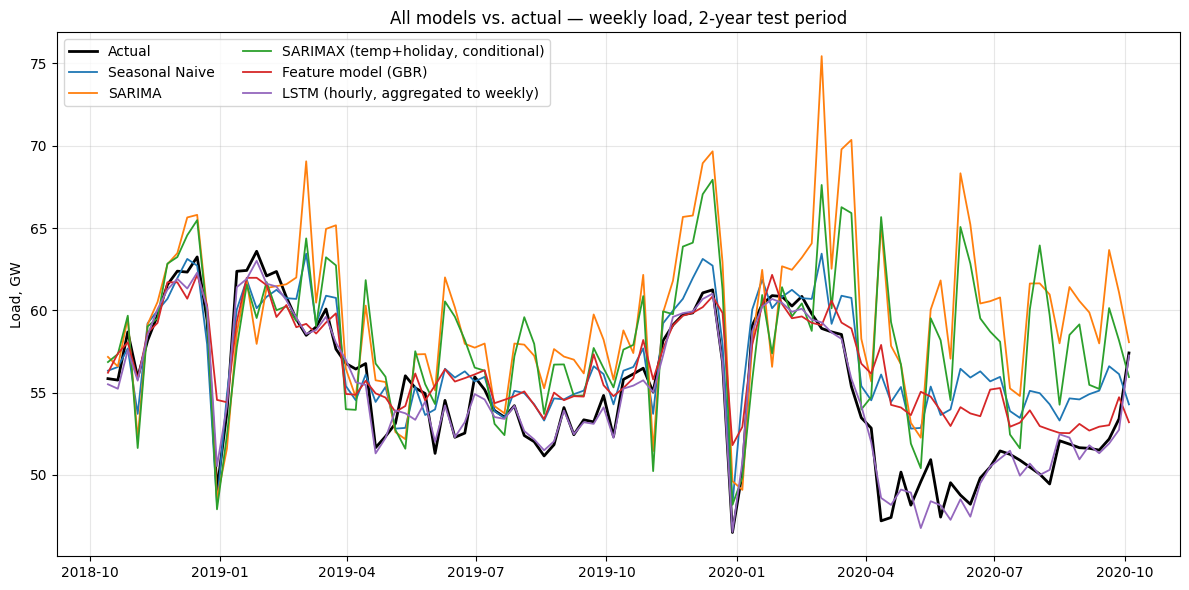

In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test.index, test, label="Actual", color="black", linewidth=2)
plot_order = ["Seasonal Naive", "SARIMA", "SARIMAX (temp+holiday, conditional)",
              "Feature model (GBR)", "LSTM (hourly, aggregated to weekly)"]
for name in plot_order:
    if name in forecasts:
        ax.plot(test.index, forecasts[name].reindex(test.index), label=name, linewidth=1.3)
ax.set_title("All models vs. actual — weekly load, 2-year test period")
ax.set_ylabel("Load, GW")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()
